In [2]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.9 MB/s eta 0:00:00


In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy.stats import skew

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# Hyperparameter tuning
import keras_tuner as kt

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("/content/Churn Modeling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.describe(include="object")

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


In [9]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop(
    columns=["RowNumber", "CustomerId", "Surname"]
)

In [13]:
print(df["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [14]:
print(df["Exited"].value_counts(normalize=True) * 100)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


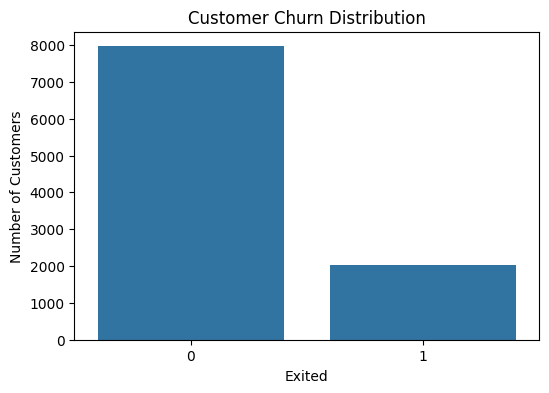

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Exited")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")

plt.show()

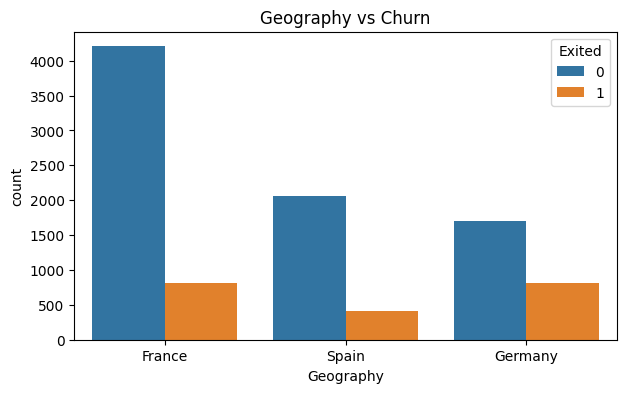

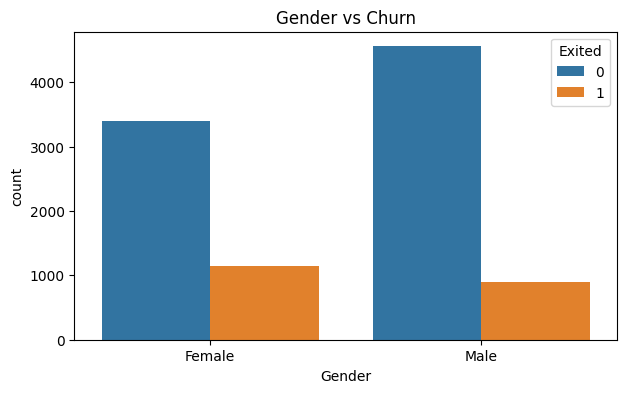

In [16]:
categorical_cols = [
    "Geography",
    "Gender"
]

for col in categorical_cols:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=col,
        hue="Exited"
    )

    plt.title(f"{col} vs Churn")

    plt.show()

In [17]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

print(numeric_cols)

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


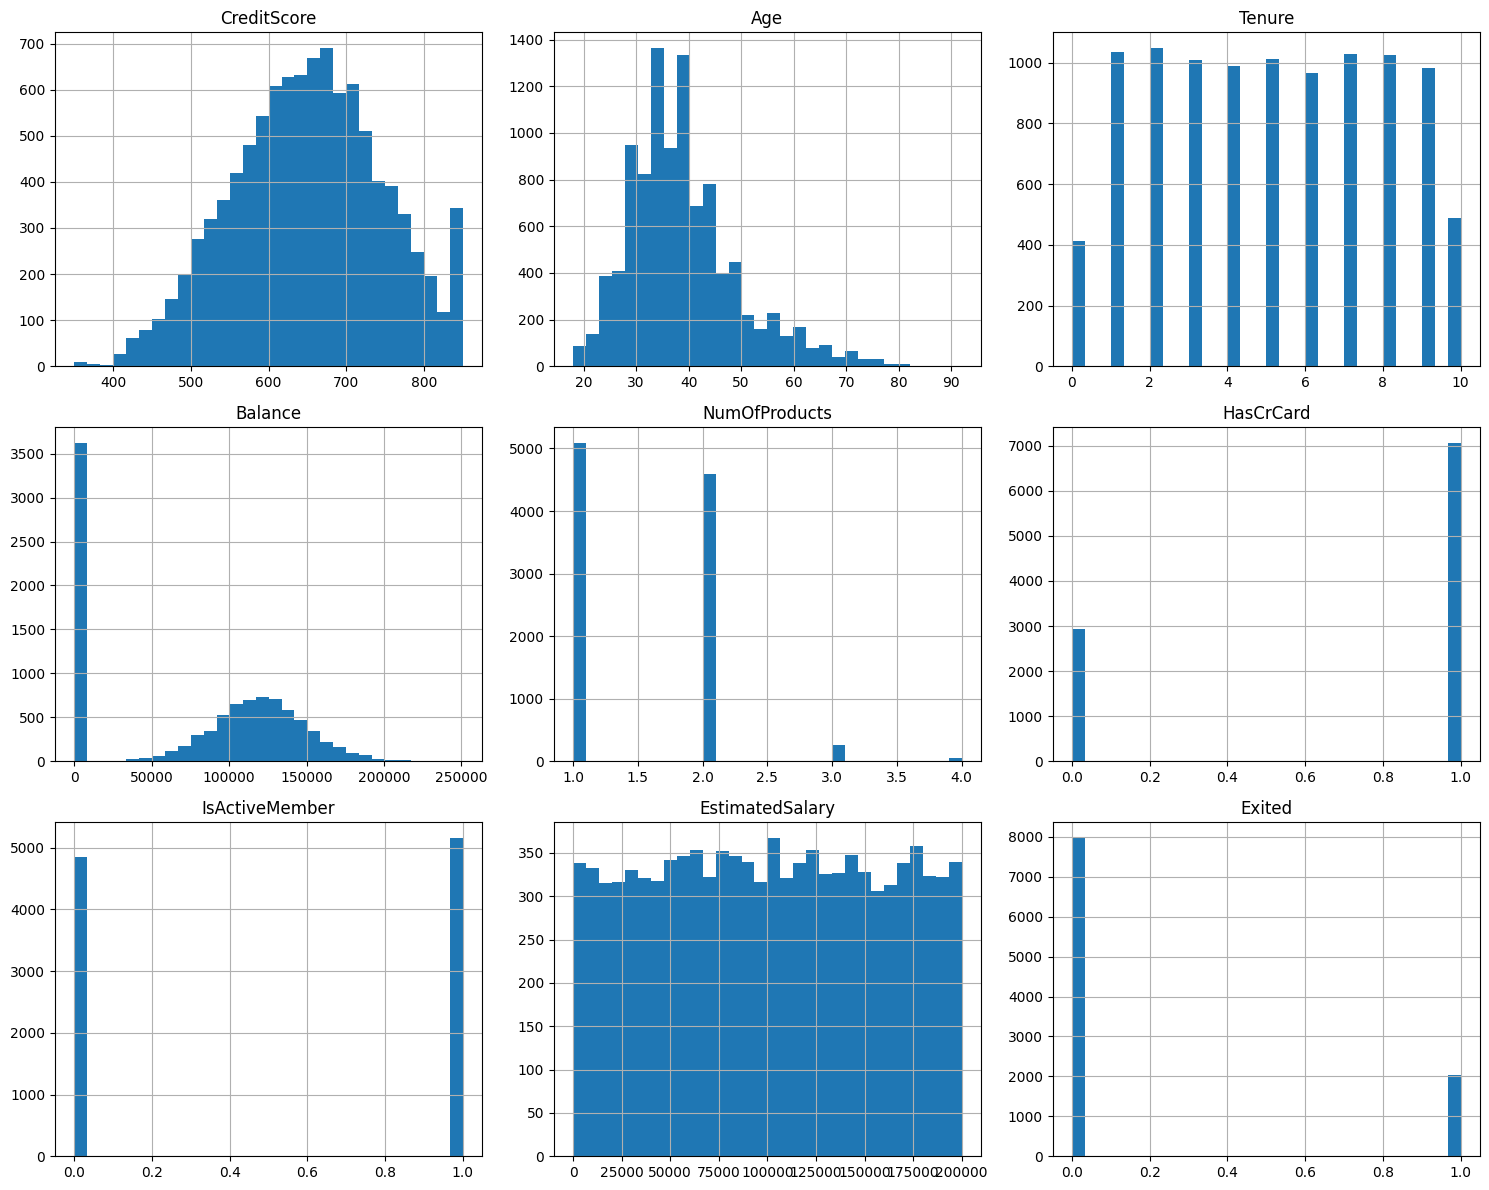

In [18]:
df[numeric_cols].hist(
    figsize=(15,12),
    bins=30
)

plt.tight_layout()
plt.show()

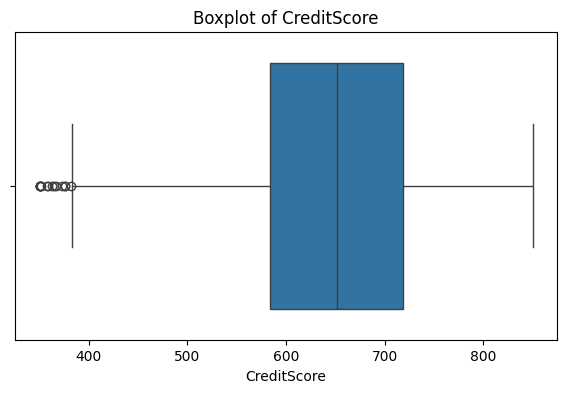

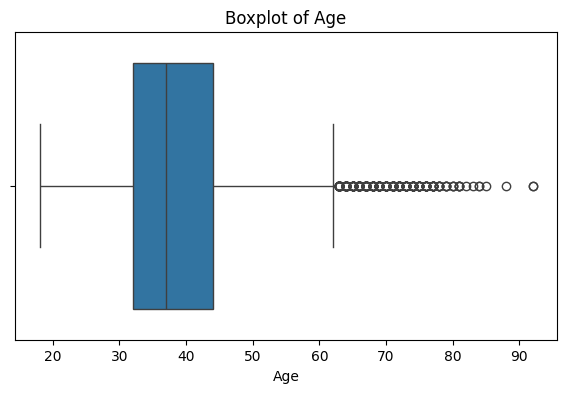

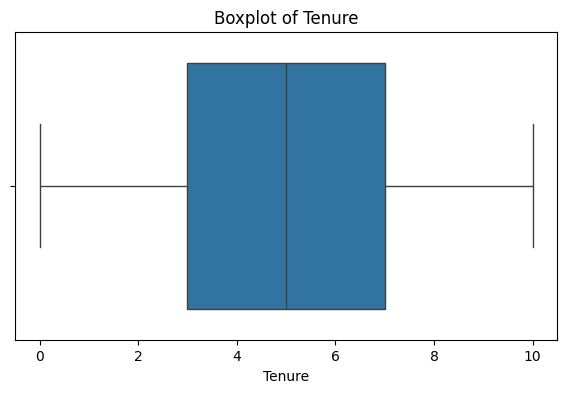

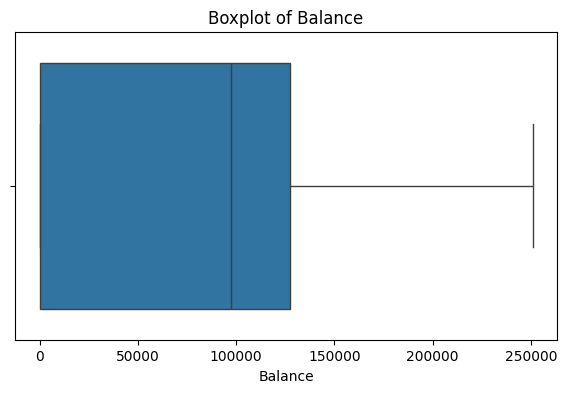

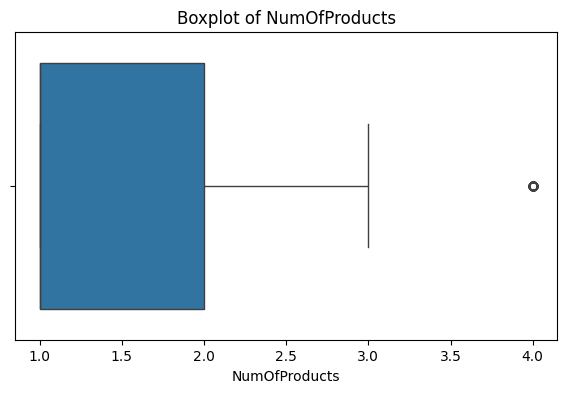

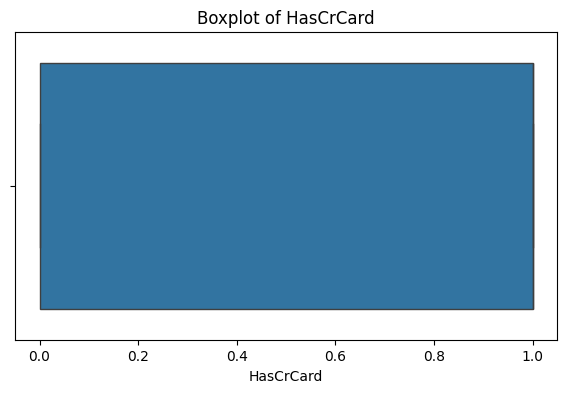

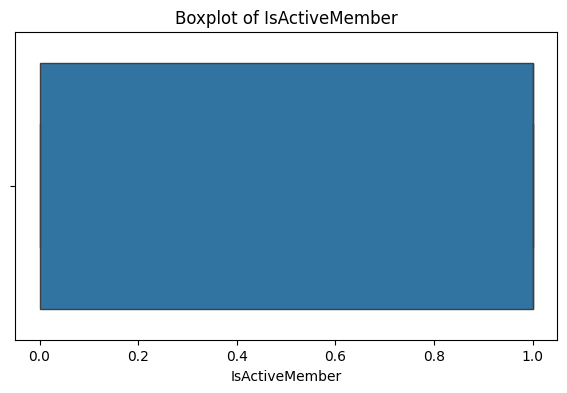

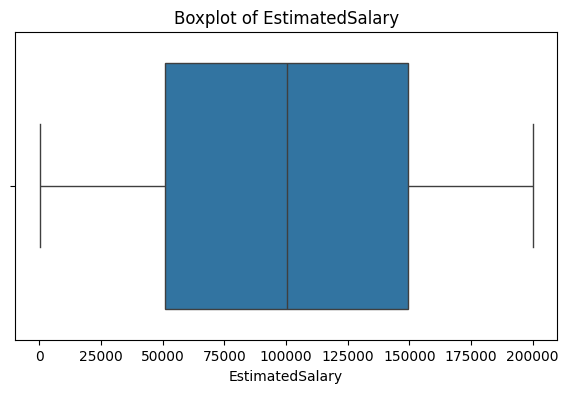

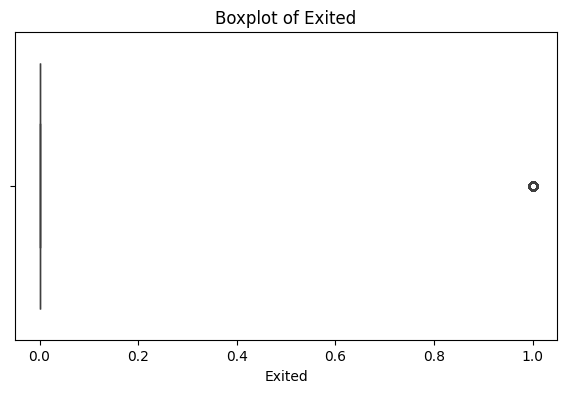

In [19]:
for col in numeric_cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

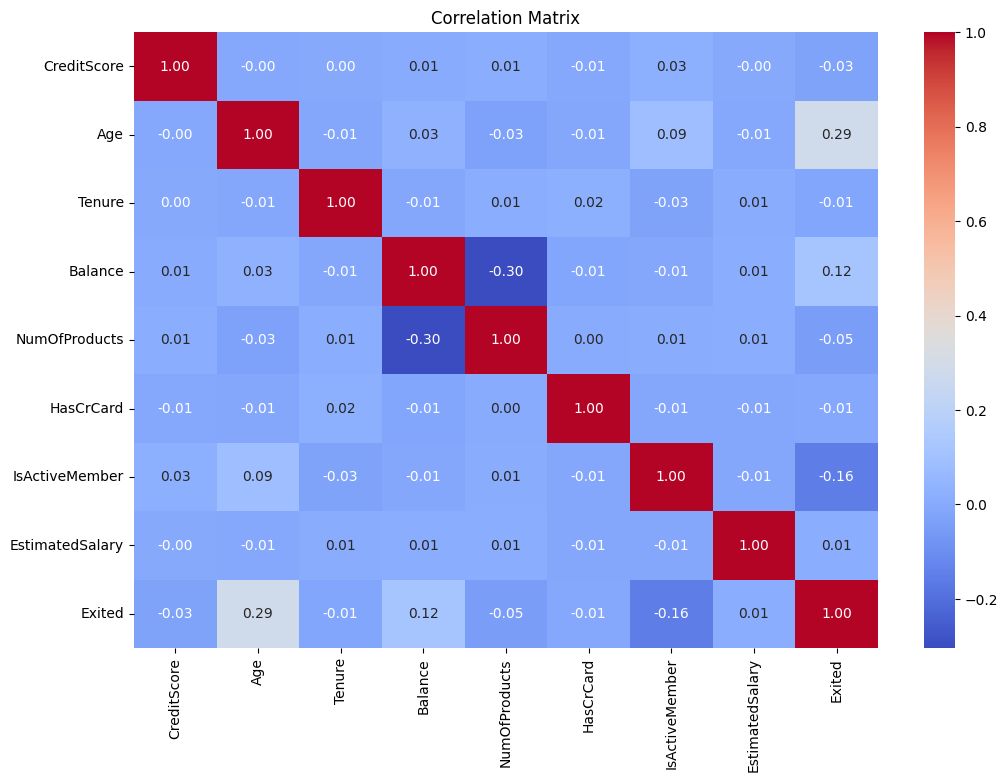

In [20]:
plt.figure(figsize=(12,8))

correlation = df[numeric_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

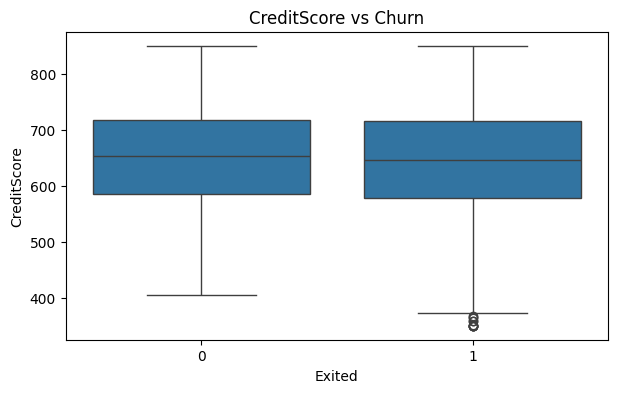

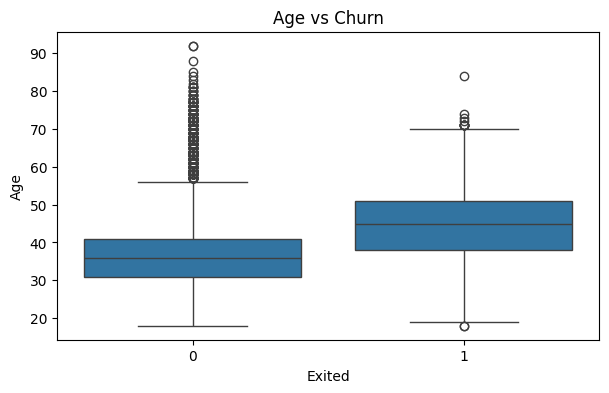

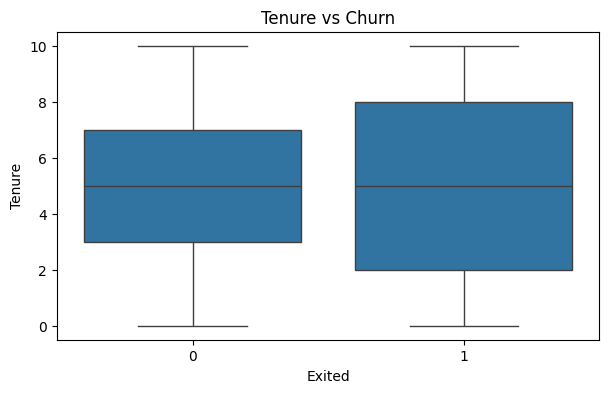

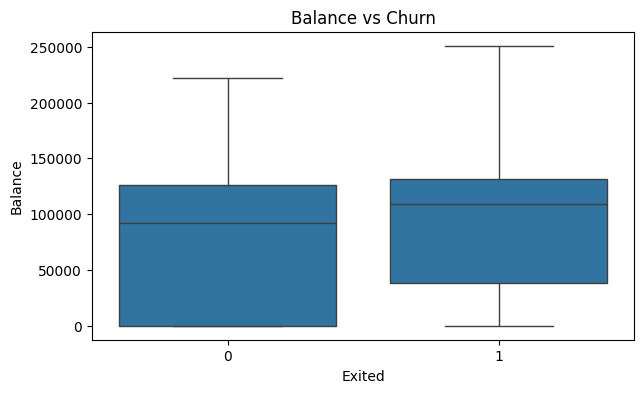

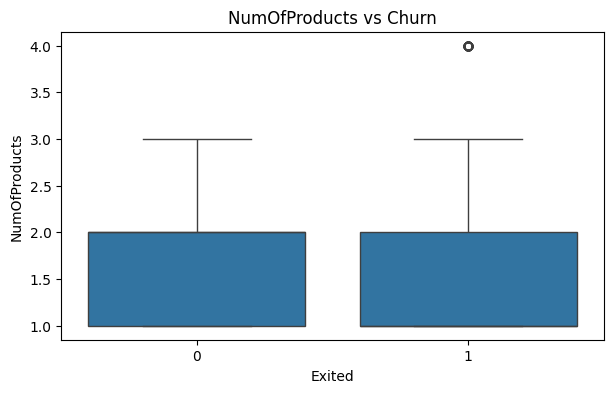

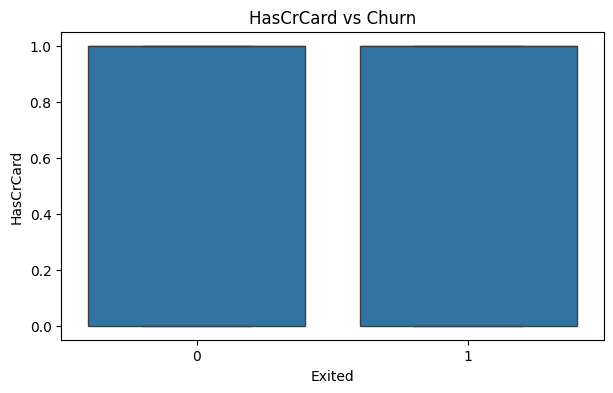

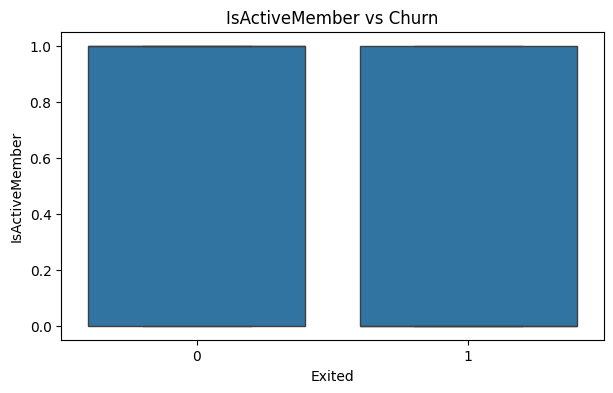

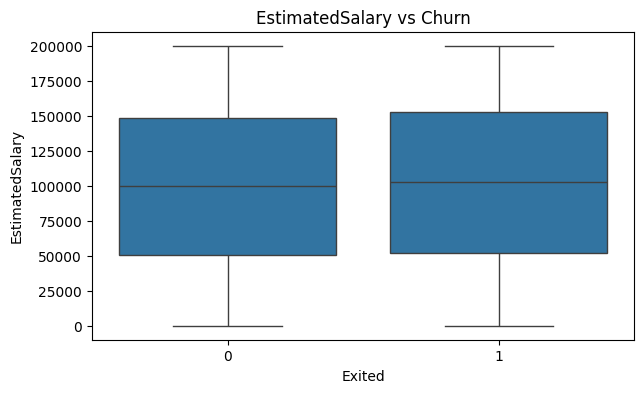

In [21]:
for col in numeric_cols:

    if col != "Exited":

        plt.figure(figsize=(7,4))

        sns.boxplot(
            data=df,
            x="Exited",
            y=col
        )

        plt.title(f"{col} vs Churn")

        plt.show()

In [22]:
numeric_features = df.select_dtypes(
    include=np.number
).drop(columns=["Exited"]).columns

skewness = df[numeric_features].skew()

print(skewness.sort_values(ascending=False))

Age                1.011320
NumOfProducts      0.745568
Tenure             0.010991
EstimatedSalary    0.002085
IsActiveMember    -0.060437
CreditScore       -0.071607
Balance           -0.141109
HasCrCard         -0.901812
dtype: float64


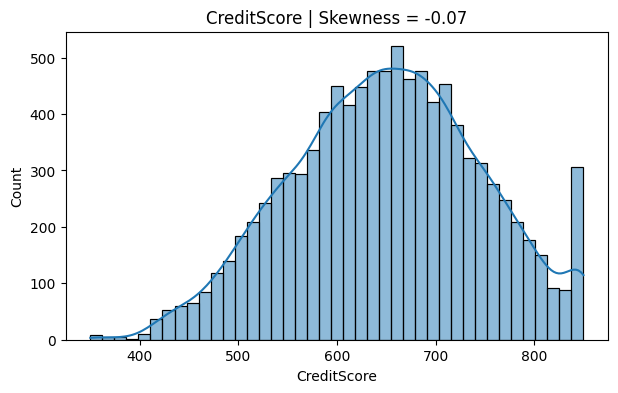

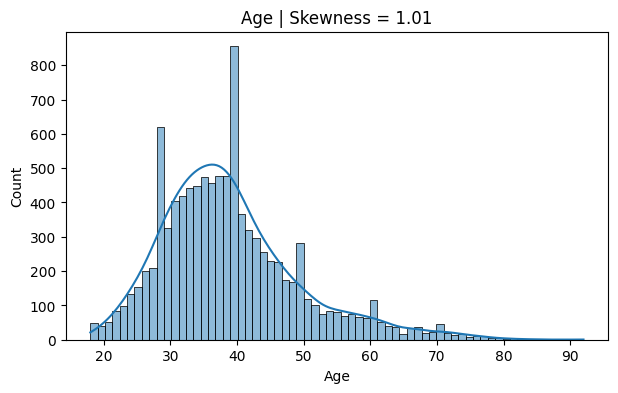

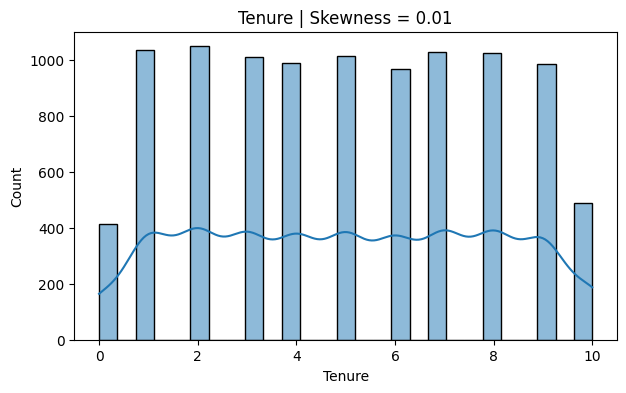

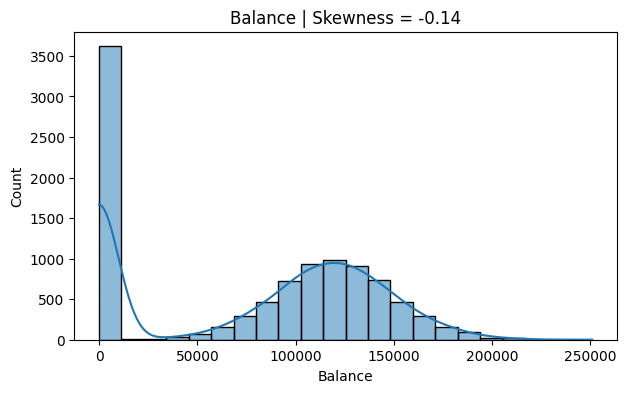

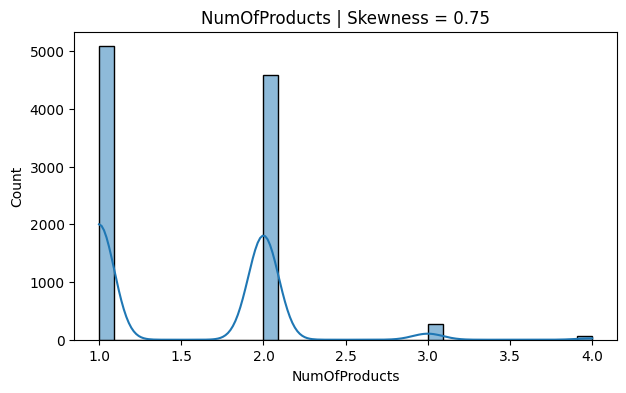

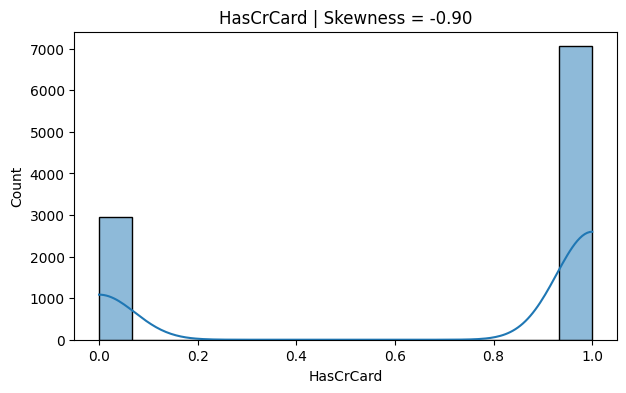

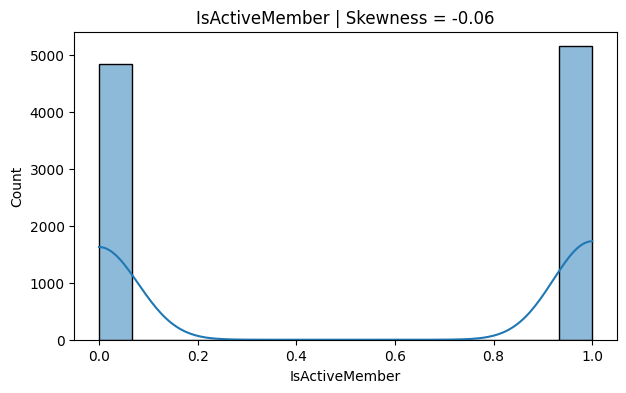

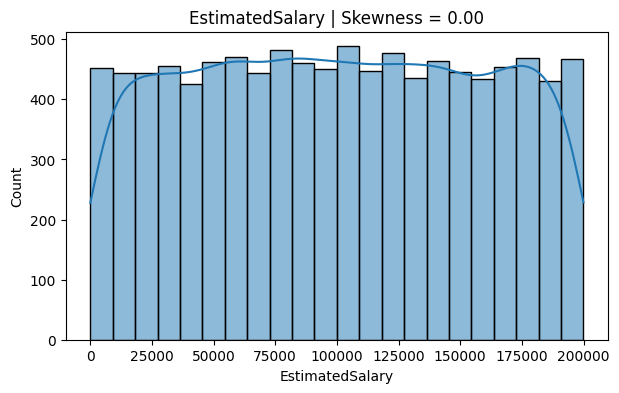

In [23]:
for col in numeric_features:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(
        f"{col} | Skewness = {df[col].skew():.2f}"
    )

    plt.show()

In [24]:
df["Balance_log"] = np.log1p(df["Balance"])

In [25]:
def detect_outliers_iqr(data, columns):

    outlier_summary = {}

    for col in columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[
            (data[col] < lower_bound) |
            (data[col] > upper_bound)
        ]

        outlier_summary[col] = len(outliers)

    return outlier_summary

In [26]:
outliers = detect_outliers_iqr(
    df,
    numeric_features
)

print(outliers)

{'CreditScore': 15, 'Age': 359, 'Tenure': 0, 'Balance': 0, 'NumOfProducts': 60, 'HasCrCard': 0, 'IsActiveMember': 0, 'EstimatedSalary': 0}


In [27]:
df = pd.get_dummies(
    df,
    columns=["Geography", "Gender"],
    drop_first=True,
    dtype=int
)

In [28]:
X = df.drop(
    columns=["Exited"]
)

y = df["Exited"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [32]:
model = Sequential([

    Dense(
        64,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [33]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8050 - loss: 0.4529 - val_accuracy: 0.8350 - val_loss: 0.4008
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8478 - loss: 0.3670 - val_accuracy: 0.8531 - val_loss: 0.3651
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8550 - loss: 0.3467 - val_accuracy: 0.8537 - val_loss: 0.3551
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8602 - loss: 0.3365 - val_accuracy: 0.8550 - val_loss: 0.3509
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8592 - loss: 0.3312 - val_accuracy: 0.8525 - val_loss: 0.3543
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8620 - loss: 0.3261 - val_accuracy: 0.8519 - val_loss: 0.3502
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8600 - loss: 0.3248 - val_accuracy: 0.8494 - val_loss: 0.3532
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8639 - loss: 0.3208 - val_accu

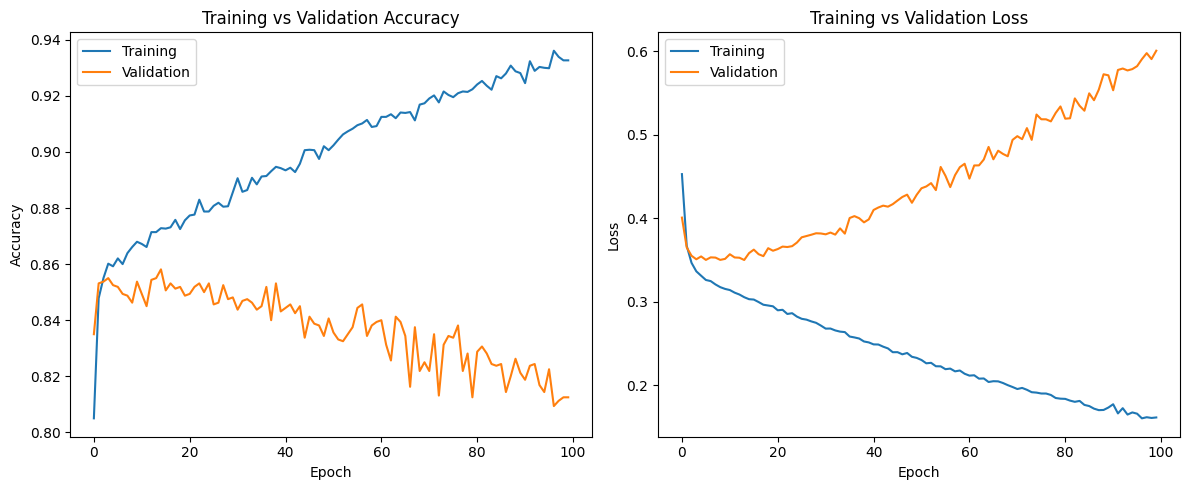

In [36]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training", "Validation"])


plt.subplot(1,2,2)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training", "Validation"])

plt.tight_layout()

plt.show()

In [37]:
model_dropout = Sequential([

    Dense(
        64,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        16,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [38]:
model_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [39]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [40]:
history_dropout = model_dropout.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7842 - loss: 0.5047 - val_accuracy: 0.8181 - val_loss: 0.4437
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8011 - loss: 0.4597 - val_accuracy: 0.8112 - val_loss: 0.4238
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8062 - loss: 0.4409 - val_accuracy: 0.8325 - val_loss: 0.4084
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8170 - loss: 0.4225 - val_accuracy: 0.8450 - val_loss: 0.3924
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8292 - loss: 0.4093 - val_accuracy: 0.8481 - val_loss: 0.3768
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8355 - loss: 0.3901 - val_accuracy: 0.8569 - val_loss: 0.3654
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8439 - loss: 0.3812 - val_accuracy: 0.8544 - val_loss: 0.3600
Epoch 8/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8381 - loss: 0.3844 - val_accu

In [41]:
checkpoint = ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [42]:
history_dropout = model_dropout.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[
        early_stopping,
        checkpoint
    ],
    verbose=1
)

Epoch 1/200
196/200 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8516 - loss: 0.3520
Epoch 1: val_loss improved from None to 0.34763, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8572 - loss: 0.3483 - val_accuracy: 0.8606 - val_loss: 0.3476
Epoch 2/200
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8656 - loss: 0.3382
Epoch 2: val_loss did not improve from 0.34763
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8608 - loss: 0.3409 - val_accuracy: 0.8587 - val_loss: 0.3486
Epoch 3/200
195/200 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8627 - loss: 0.3388
Epoch 3: val_loss did not improve from 0.34763
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8630 - loss: 0.3404 - val_accuracy: 0.8612 - val_loss: 0.3477
Epoch 4/200
198/200 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8616 - loss: 0.3357
Epoch 4: val_loss did not improve from 0.34763
200/200 ━━━━━━━━━━━━━━━━

In [43]:
test_loss, test_accuracy = model_dropout.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.33749693632125854
Test Accuracy: 0.8634999990463257


In [45]:
y_pred_probability = model_dropout.predict(
    X_test_scaled
).ravel()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [46]:
y_pred = (
    y_pred_probability >= 0.5
).astype(int)

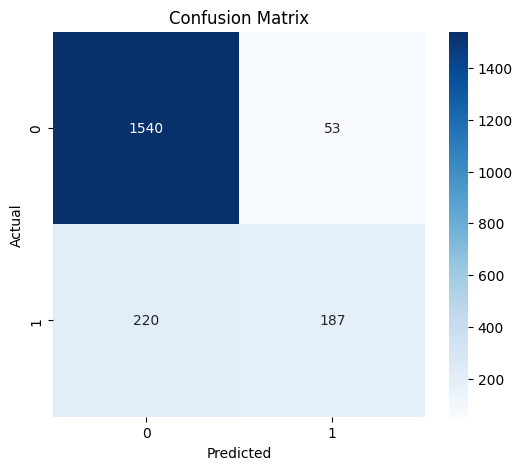

In [47]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [48]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



In [49]:
auc = roc_auc_score(
    y_test,
    y_pred_probability
)

print("ROC-AUC:", auc)

ROC-AUC: 0.8602454534657924


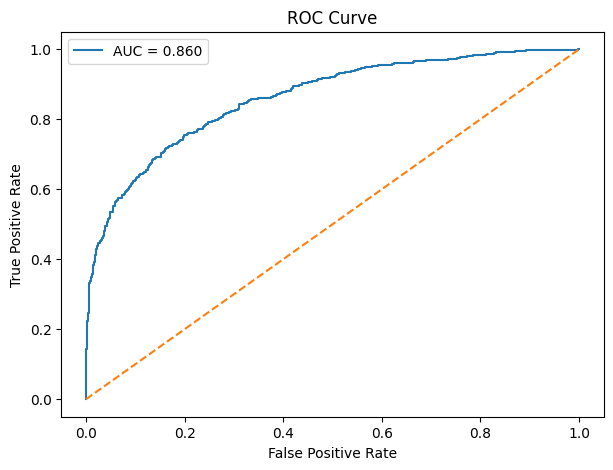

In [50]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_probability
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [51]:
def build_model(hp):

    model = keras.Sequential()

    # Number of hidden layers
    num_layers = hp.Int(
        "num_layers",
        min_value=1,
        max_value=4,
        step=1
    )

    for i in range(num_layers):

        units = hp.Int(
            f"units_{i}",
            min_value=16,
            max_value=128,
            step=16
        )

        activation = hp.Choice(
            f"activation_{i}",
            values=["relu", "tanh"]
        )

        model.add(
            Dense(
                units=units,
                activation=activation
            )
        )

        dropout_rate = hp.Float(
            f"dropout_{i}",
            min_value=0.0,
            max_value=0.5,
            step=0.1
        )

        model.add(
            Dropout(dropout_rate)
        )

    # Output layer
    model.add(
        Dense(
            1,
            activation="sigmoid"
        )
    )

    # Optimizer selection
    optimizer_name = hp.Choice(
        "optimizer",
        values=["adam", "rmsprop"]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[
            0.001,
            0.0005,
            0.0001
        ]
    )

    if optimizer_name == "adam":

        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    else:

        optimizer = keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [52]:
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=30,
    directory="keras_tuner",
    project_name="bank_churn"
)

In [53]:
tuner.search(
    X_train_scaled,
    y_train,
    validation_data=(
        X_val_scaled,
        y_val
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Trial 30 Complete [00h 00m 20s]
val_accuracy: 0.8637499809265137

Best val_accuracy So Far: 0.8675000071525574
Total elapsed time: 00h 21m 35s


In [54]:
best_hps = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

In [55]:
print(
    "Best number of layers:",
    best_hps.get("num_layers")
)

print(
    "Best optimizer:",
    best_hps.get("optimizer")
)

print(
    "Best learning rate:",
    best_hps.get("learning_rate")
)

Best number of layers: 1
Best optimizer: rmsprop
Best learning rate: 0.001


In [56]:
for i in range(
    best_hps.get("num_layers")
):

    print(
        f"Layer {i+1} units:",
        best_hps.get(f"units_{i}")
    )

    print(
        f"Layer {i+1} activation:",
        best_hps.get(f"activation_{i}")
    )

    print(
        f"Layer {i+1} dropout:",
        best_hps.get(f"dropout_{i}")
    )

Layer 1 units: 96
Layer 1 activation: tanh
Layer 1 dropout: 0.1


In [57]:
best_model = tuner.get_best_models(
    num_models=1
)[0]

In [58]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (32, 96)               │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 96)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
final_checkpoint = ModelCheckpoint(
    "final_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [61]:
final_history = best_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(
        X_val_scaled,
        y_val
    ),
    epochs=200,
    batch_size=32,
    callbacks=[
        final_checkpoint,
        final_early_stopping
    ],
    verbose=1
)

Epoch 1/200
195/200 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8554 - loss: 0.3485
Epoch 1: val_loss improved from None to 0.34536, saving model to final_best_model.keras

Epoch 1: finished saving model to final_best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8577 - loss: 0.3428 - val_accuracy: 0.8662 - val_loss: 0.3454
Epoch 2/200
194/200 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8624 - loss: 0.3353
Epoch 2: val_loss did not improve from 0.34536
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8562 - loss: 0.3443 - val_accuracy: 0.8656 - val_loss: 0.3471
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8564 - loss: 0.3375
Epoch 3: val_loss did not improve from 0.34536
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8561 - loss: 0.3436 - val_accuracy: 0.8594 - val_loss: 0.3488
Epoch 4/200
192/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8496 - loss: 0.3517
Epoch 4: val_loss did not improve from 0.34536
200/200 ━━━━━

In [62]:
final_loss, final_accuracy = best_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Final Test Accuracy:", final_accuracy)

Final Test Accuracy: 0.871999979019165


In [63]:
final_probability = best_model.predict(
    X_test_scaled
).ravel()

final_prediction = (
    final_probability >= 0.5
).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [64]:
print(
    classification_report(
        y_test,
        final_prediction
    )
)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.87      0.87      0.86      2000



In [65]:
final_auc = roc_auc_score(
    y_test,
    final_probability
)

print("Final ROC-AUC:", final_auc)

Final ROC-AUC: 0.8656653571907809


In [66]:
results = []

# Basic ANN
basic_probability = model.predict(
    X_test_scaled
).ravel()

basic_prediction = (
    basic_probability >= 0.5
).astype(int)

results.append({
    "Model": "Basic ANN",
    "Accuracy": accuracy_score(
        y_test,
        basic_prediction
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        basic_probability
    )
})


# Dropout ANN
dropout_probability = model_dropout.predict(
    X_test_scaled
).ravel()

dropout_prediction = (
    dropout_probability >= 0.5
).astype(int)

results.append({
    "Model": "ANN + Dropout",
    "Accuracy": accuracy_score(
        y_test,
        dropout_prediction
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        dropout_probability
    )
})


# Tuned ANN
tuned_probability = best_model.predict(
    X_test_scaled
).ravel()

tuned_prediction = (
    tuned_probability >= 0.5
).astype(int)

results.append({
    "Model": "KerasTuner ANN",
    "Accuracy": accuracy_score(
        y_test,
        tuned_prediction
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        tuned_probability
    )
})


results_df = pd.DataFrame(results)

print(results_df)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
            Model  Accuracy   ROC-AUC
0       Basic ANN    0.8015  0.794533
1   ANN + Dropout    0.8635  0.860245
2  KerasTuner ANN    0.8720  0.865665


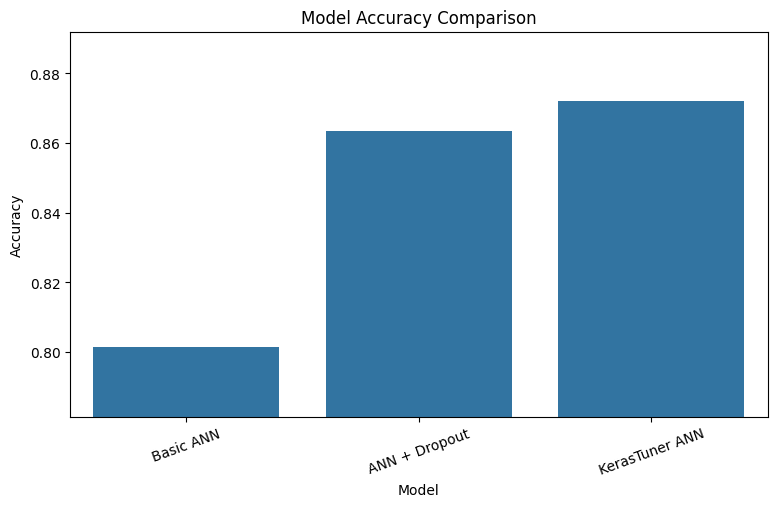

In [67]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.ylim(
    results_df["Accuracy"].min() - 0.02,
    results_df["Accuracy"].max() + 0.02
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

comparison = []

models = {
    "Basic ANN": (
        basic_prediction,
        basic_probability
    ),

    "ANN + Dropout": (
        dropout_prediction,
        dropout_probability
    ),

    "KerasTuner ANN": (
        tuned_prediction,
        tuned_probability
    )
}

for name, (pred, prob) in models.items():

    comparison.append({

        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            pred
        ),

        "Precision": precision_score(
            y_test,
            pred
        ),

        "Recall": recall_score(
            y_test,
            pred
        ),

        "F1": f1_score(
            y_test,
            pred
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            prob
        )
    })

comparison_df = pd.DataFrame(comparison)

print(comparison_df)

            Model  Accuracy  Precision    Recall        F1   ROC-AUC
0       Basic ANN    0.8015   0.512315  0.511057  0.511685  0.794533
1   ANN + Dropout    0.8635   0.779167  0.459459  0.578053  0.860245
2  KerasTuner ANN    0.8720   0.796078  0.498771  0.613293  0.865665
